## 케라스 모델을 만드는 여러 방법

- Sequential 모델 : 가장 시작하기 쉬운 API, 하나의 파이썬 리스트로 단순히 층을 쌓을 수만 있다.

- 함수형 API : 그래프 같은 모델 구조를 주로 다룬다. 사용성과 유연성 사이의 적절한 중간 지점에 해당된다.

- Model 서브클래싱 : 모든 것을 밑바닥부터 직접 만들 수 있는 저수준 방법

### Sequential 모델

- 가장 간단한 방법으로, Sequential 클래스를 사용해 만든다.

#### Sequential 클래스

In [2]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

2026-02-17 15:22:49.205313: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory
2026-02-17 15:22:49.205407: W tensorflow/stream_executor/cuda/cuda_driver.cc:269] failed call to cuInit: UNKNOWN ERROR (303)
2026-02-17 15:22:49.205475: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (BOOK-HU2G0S14U5): /proc/driver/nvidia/version does not exist
2026-02-17 15:22:49.207236: I tensorflow/core/platform/cpu_feature_guard.cc:151] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


#### 점진적으로 Sequential 모델 만들기

In [3]:
model = keras.Sequential()
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

#### 가중치를 만들기 위해 모델 호출

In [4]:
model.build(input_shape=(None,3))
model.weights

[<tf.Variable 'dense_2/kernel:0' shape=(3, 64) dtype=float32, numpy=
 array([[ 2.33136415e-01, -9.76806283e-02, -1.57584205e-01,
         -1.49991482e-01,  1.66944623e-01, -1.82173535e-01,
         -1.39236927e-01, -2.01687634e-01, -1.76533163e-01,
         -8.90232623e-02, -3.07235122e-03,  1.17020428e-01,
         -1.90728158e-01, -2.93743074e-01, -1.74823970e-01,
          2.02474952e-01,  2.98579872e-01,  3.82604301e-02,
          1.88862979e-02, -1.99069381e-02, -1.53068900e-02,
         -6.37972951e-02,  2.58005798e-01, -1.48635596e-01,
         -4.77037430e-02, -2.02667370e-01,  1.61439270e-01,
         -1.63403243e-01, -1.97767377e-01,  2.80043006e-01,
         -2.23295540e-01, -2.61918843e-01,  5.29038906e-02,
         -2.08757520e-02, -7.51552433e-02, -4.25052345e-02,
          2.79380322e-01,  2.25628316e-02,  2.76301861e-01,
          7.26530850e-02,  1.33967578e-01,  1.13650590e-01,
         -1.19847983e-01, -2.73613095e-01, -1.32255867e-01,
         -8.08364302e-02, -2.92

In [5]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_2 (Dense)             (None, 64)                256       
                                                                 
 dense_3 (Dense)             (None, 10)                650       
                                                                 
Total params: 906
Trainable params: 906
Non-trainable params: 0
_________________________________________________________________


#### name 매개변수로 모델과 층에 이름 지정하기

In [6]:
model = keras.Sequential(name='my_model')
model.add(layers.Dense(64, activation='relu', name='dense_1'))
model.add(layers.Dense(10, activation='softmax', name='dense_2'))
model.build((None,3))
model.summary()

Model: "my_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_1 (Dense)             (None, 64)                256       
                                                                 
 dense_2 (Dense)             (None, 10)                650       
                                                                 
Total params: 906
Trainable params: 906
Non-trainable params: 0
_________________________________________________________________


#### 모델의 입력크기를 미리 지정하기

In [7]:
model = keras.Sequential()
model.add(keras.Input(shape=(3,)))
model.add(layers.Dense(64, activation='relu'))
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_4 (Dense)             (None, 64)                256       
                                                                 
Total params: 256
Trainable params: 256
Non-trainable params: 0
_________________________________________________________________


In [8]:
model.add(layers.Dense(10, activation='softmax'))
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_4 (Dense)             (None, 64)                256       
                                                                 
 dense_5 (Dense)             (None, 10)                650       
                                                                 
Total params: 906
Trainable params: 906
Non-trainable params: 0
_________________________________________________________________


### 함수형 API

- 다중 입력, 다중 출력, 또는 비선형적인 구조를 가진 모델에서 Sequential 모델은 적용이 제한적이다. 이런 경우에는 함수형 API를 사용해서 모델을 만들어 사용한다.

#### 2개의 Dense층을 가진 간단한 함수형 모델

In [1]:
from tensorflow import keras
from tensorflow.keras import layers

inputs = keras.Input(shape=(3,), name='input_layer')
features = layers.Dense(64, activation='relu')(inputs)
outputs = layers.Dense(10, activation='softmax')(features)
model = keras.Model(inputs=inputs, outputs=outputs, name='my_model')
model.summary()

2026-02-17 16:08:19.897159: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-02-17 16:08:19.897236: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.


Model: "my_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_layer (InputLayer)    [(None, 3)]               0         
                                                                 
 dense (Dense)               (None, 64)                256       
                                                                 
 dense_1 (Dense)             (None, 10)                650       
                                                                 
Total params: 906
Trainable params: 906
Non-trainable params: 0
_________________________________________________________________


2026-02-17 16:08:21.196583: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory
2026-02-17 16:08:21.196613: W tensorflow/stream_executor/cuda/cuda_driver.cc:269] failed call to cuInit: UNKNOWN ERROR (303)
2026-02-17 16:08:21.196636: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (BOOK-HU2G0S14U5): /proc/driver/nvidia/version does not exist
2026-02-17 16:08:21.196868: I tensorflow/core/platform/cpu_feature_guard.cc:151] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


#### 다중 입력, 다중 출력 함수형 모델

In [2]:
vocabulary_size = 10000
num_tags = 100
num_departments = 4

title = keras.Input(shape=(vocabulary_size,), name='title')
text_body = keras.Input(shape=(vocabulary_size,), name='text_body')
tags = keras.Input(shape=(num_tags,), name='tags')

features = layers.Concatenate()([title, text_body, tags])
features = layers.Dense(64, activation='relu')(features)

priority = layers.Dense(1, activation='sigmoid', name='priority')(features)
department = layers.Dense(
    num_departments, activation='softmax', name='department'
)(features)

model = keras.Model(inputs=[title, text_body, tags], outputs=[priority, department])

In [3]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 title (InputLayer)             [(None, 10000)]      0           []                               
                                                                                                  
 text_body (InputLayer)         [(None, 10000)]      0           []                               
                                                                                                  
 tags (InputLayer)              [(None, 100)]        0           []                               
                                                                                                  
 concatenate (Concatenate)      (None, 20100)        0           ['title[0][0]',                  
                                                                  'text_body[0][0]',          

#### 입력과 타깃 배열 리스트를 전달하여 모델 훈련하기

In [4]:
import numpy as np

num_samples = 1280

title_data = np.random.randint(0, 2, size=(num_samples, vocabulary_size))
text_body_data = np.random.randint(0, 2, size=(num_samples, vocabulary_size))
tags_data = np.random.randint(0, 2, size=(num_samples, num_tags))

priority_data = np.random.random(size=(num_samples, 1))
department_data = np.random.randint(0,2, size=(num_samples, num_departments))

model.compile(optimizer='rmsprop',
              loss=['binary_crossentropy', 'categorical_crossentropy'],
              metrics=[['mean_absolute_error'],['accuracy']])
model.fit(
    [title_data, text_body_data, tags_data],
    [priority_data, department_data],
    epochs=1
)

model.evaluate([title_data, text_body_data, tags_data], [priority_data, department_data])
priority_preds, department_preds = model.predict([title_data, text_body_data, tags_data])

40/40 [==============================] - 0s 4ms/step - loss: 51.6504 - priority_loss: 9.0166 - department_loss: 42.6338 - priority_mean_absolute_error: 0.4926 - department_accuracy: 0.5273


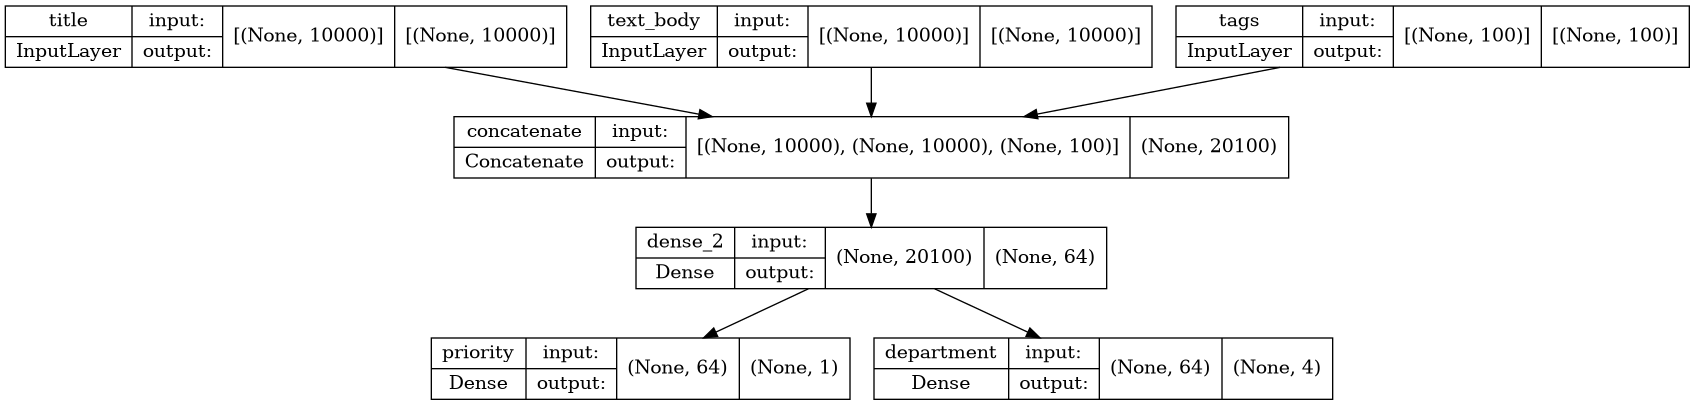

In [6]:
keras.utils.plot_model(model, 'ticket_classifier.png', show_shapes=True)

#### 함수형 모델에 있는 층의 입력과 출력을 출력하기

In [7]:
print(model.layers)
print(model.layers[3].input)
print(model.layers[3].output)

[<keras.engine.input_layer.InputLayer object at 0x7aef3a91a7f0>, <keras.engine.input_layer.InputLayer object at 0x7aef3a91a550>, <keras.engine.input_layer.InputLayer object at 0x7aef3a91a820>, <keras.layers.merge.Concatenate object at 0x7aef3a91ad30>, <keras.layers.core.dense.Dense object at 0x7aef3a91ab20>, <keras.layers.core.dense.Dense object at 0x7aefa1faa0d0>, <keras.layers.core.dense.Dense object at 0x7aef3a93a940>]
[<KerasTensor: shape=(None, 10000) dtype=float32 (created by layer 'title')>, <KerasTensor: shape=(None, 10000) dtype=float32 (created by layer 'text_body')>, <KerasTensor: shape=(None, 100) dtype=float32 (created by layer 'tags')>]
KerasTensor(type_spec=TensorSpec(shape=(None, 20100), dtype=tf.float32, name=None), name='concatenate/concat:0', description="created by layer 'concatenate'")


#### 중간층의 출력을 재사용해서 새로운 모델 만들기

In [8]:
features = model.layers[4].output
difficulty = layers.Dense(3, activation='softmax', name='difficulty')(features)
new_model = keras.Model(
    inputs = [title, text_body, tags],
    outputs = [priority, department, difficulty]
)

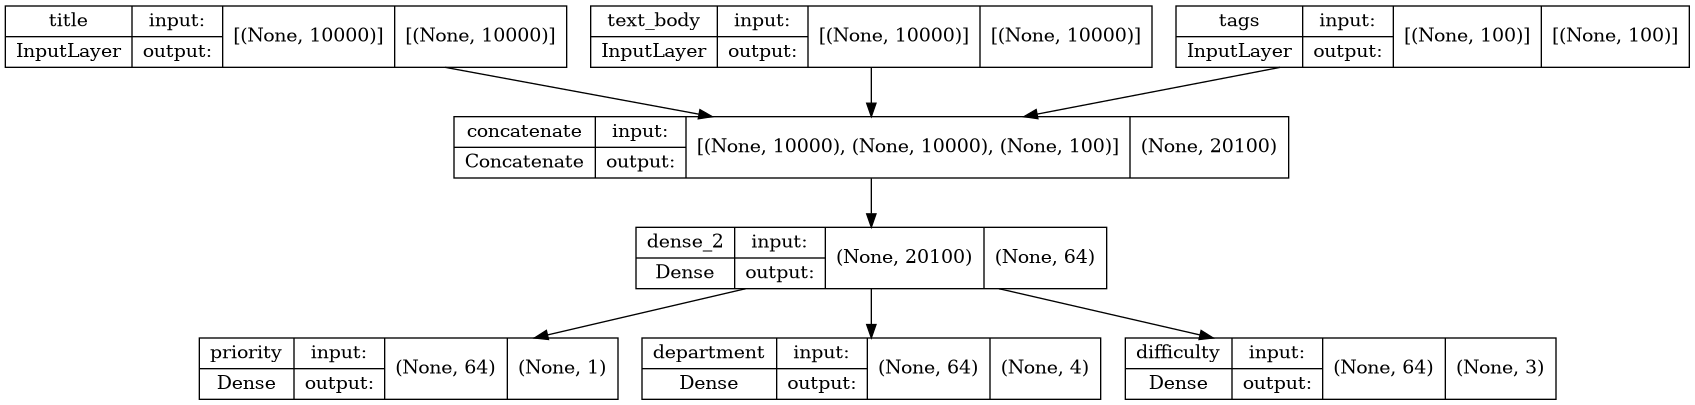

In [9]:
keras.utils.plot_model(new_model, 'ticket_classifier_with_difficulty.png', show_shapes=True)

### Model 서브클래싱

- 모델 구축 패턴 중 가장 고급 방법이다. 

- __ init __() 메서드에서 모델이 사용할 층을 정의한다.

- call() 메서드에서 앞서 만든 층을 사용하여 모델의 정방향 패스를 정의한다.

- 서브클래스의 객체를 만들고 데이터와 함께 호출하여 가중치를 만든다.

#### 간단한 서브클래싱 모델

In [1]:
from tensorflow import keras
from tensorflow.keras import layers

2026-02-18 01:38:13.046826: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-02-18 01:38:13.046882: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.


In [2]:
class CustomerTicketModel(keras.Model):
    def __init__(self, num_departments):
        super().__init__()
        self.concat_layer = layers.Concatenate()
        self.mixing_layer = layers.Dense(64, activation='relu')
        self.priority_scorer = layers.Dense(1, activation='sigmoid')
        self.department_classifier = layers.Dense(
            num_departments, activation='softmax'
        )
    def call(self,inputs):
        title = inputs['title']
        text_body = inputs['text_body']
        tags = inputs['tags']
        features = self.concat_layer([title, text_body, tags])
        features = self.mixing_layer(features)
        priority = self.priority_scorer(features)
        department = self.department_classifier(features)
        return priority, department

In [3]:
import numpy as np

num_samples = 1280
vocabulary_size = 10000
num_tags = 4
num_departments = 4

title_data = np.random.randint(0, 2, size=(num_samples, vocabulary_size))
text_body_data = np.random.randint(0, 2, size=(num_samples, vocabulary_size))
tags_data = np.random.randint(0, 2, size=(num_samples, num_tags))

In [4]:
model = CustomerTicketModel(num_departments=num_departments)
priority, department = model(
    {'title': title_data, 'text_body': text_body_data, 'tags': tags_data}
)

2026-02-18 01:38:26.616902: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory
2026-02-18 01:38:26.616941: W tensorflow/stream_executor/cuda/cuda_driver.cc:269] failed call to cuInit: UNKNOWN ERROR (303)
2026-02-18 01:38:26.616957: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (BOOK-HU2G0S14U5): /proc/driver/nvidia/version does not exist
2026-02-18 01:38:26.618017: I tensorflow/core/platform/cpu_feature_guard.cc:151] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [5]:
model.compile(optimizer='rmsprop',
              loss=['mean_squared_error', 'categorical_crossentropy'],
              metrics=[['mean_absolute_error'], ['accuracy']])

model.fit({'title': title_data, 'text_body': text_body_data, 'tags': tags_data},
          [priority, department],
          epochs=1)

model.evaluate({'title': title_data, 'text_body': text_body_data, 'tags': tags_data},
               [priority, department])

priority_preds, department_preds = model.predict({'title': title_data, 'text_body': text_body_data, 'tags': tags_data})

40/40 [==============================] - 0s 4ms/step - loss: 1.4049 - output_1_loss: 0.0231 - output_2_loss: 1.3818 - output_1_mean_absolute_error: 0.1241 - output_2_accuracy: 0.5391


### 여러 방식을 혼합하여 사용하기

- 케라스 API로 만든 모델은 Sequential 모델, 함수형 모델 또는 밑바닥부터 만든 서브클래싱 모델인지에 상관없이 부드럽게 서로 상호 운영할 수 있다.

#### 서브클래싱한 모델을 포함하는 함수형 모델 만들기

In [6]:
class Classifier(keras.Model):
    def __init__(self, num_classes=2):
        super().__init__()
        if num_classes == 2:
            num_units = 1
            activation = 'sigmoid'
        else:
            num_units = num_classes
            activation = 'softmax'
        self.dense = layers.Dense(num_units, activation=activation)

    def call(self, inputs):
        return self.dense(inputs)
    
inputs = keras.Input(shape=(3,))
features = layers.Dense(64, activation='relu')(inputs)
outputs = Classifier(num_classes=10)(features)
model = keras.Model(inputs=inputs, outputs=outputs)

#### 함수형 모델을 포함하는 서브클래싱 모델 만들기

In [7]:
inputs = keras.Input(shape=(64,))
outputs = layers.Dense(1, activation='sigmoid')(inputs)
binary_classifier = keras.Model(inputs=inputs, outputs=outputs)

class MyModel(keras.Model):
    def __init__(self, num_classes=2):
        super().__init__()
        self.dense = layers.Dense(64, activation='relu')
        self.classifier = binary_classifier

    def call(self, inputs):
        features = self.dense(inputs)
        return self.classifier(features)
    
model = MyModel()

#### 표준 워크플로: compile(), fit(), evaluate(), predict()

In [8]:
from tensorflow.keras.datasets import mnist

def get_mnist_model():
    inputs = keras.Input(shape=(28*28),)
    features = layers.Dense(512, activation='relu')(inputs)
    features = layers.Dropout(0.5)(features)
    outputs = layers.Dense(10, activation='softmax')(features)
    model = keras.Model(inputs, outputs)
    return model

(images, labels), (test_images, test_labels) = mnist.load_data()
images = images.reshape((60000, 28*28)).astype('float32') / 255
test_images = test_images.reshape((10000, 28*28)).astype('float32') / 255
train_images, val_images = images[10000:], images[:10000]
train_labels, val_labels = labels[10000:], labels[:10000]

model = get_mnist_model()
model.compile(optimizer='rmsprop', # 옵티마이저, 최소화할 손실 함수, 모니터링할 지표를 지정하여 모델을 컴파일한다.
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.fit(train_images, train_labels, # fit() 메서드를 사용해서 모델을 훈련한다. 본 적 없는 데이터에 대한 성능을 모니터링하기 위해 검증 데이터를 함께 제공한다.
          epochs=3,
          validation_data=(val_images, val_labels))
test_metrics = model.evaluate(test_images, test_labels) # evaluate() 메서드를 사용해서 모델의 성능을 평가한다.
predictions = model.predict(test_images) # predict() 메서드를 사용해서 모델을 사용하여 새로운 데이터에 대한 예측을 생성한다.

Epoch 1/3
1563/1563 [==============================] - 8s 5ms/step - loss: 0.2896 - accuracy: 0.9142 - val_loss: 0.1560 - val_accuracy: 0.9579
Epoch 2/3
1563/1563 [==============================] - 8s 5ms/step - loss: 0.1651 - accuracy: 0.9539 - val_loss: 0.1167 - val_accuracy: 0.9685
Epoch 3/3
313/313 [==============================] - 0s 1ms/step - loss: 0.1081 - accuracy: 0.9741


#### Callback 클래스를 상속하여 사용자 정의 콜백 만들기

Epoch 1/10
1563/1563 [==============================] - 9s 5ms/step - loss: 0.2975 - accuracy: 0.9109 - val_loss: 0.1460 - val_accuracy: 0.9602
Epoch 2/10
1563/1563 [==============================] - 8s 5ms/step - loss: 0.1665 - accuracy: 0.9530 - val_loss: 0.1199 - val_accuracy: 0.9674
Epoch 3/10
1563/1563 [==============================] - 7s 4ms/step - loss: 0.1416 - accuracy: 0.9629 - val_loss: 0.1120 - val_accuracy: 0.9724
Epoch 4/10
1563/1563 [==============================] - 5s 3ms/step - loss: 0.1271 - accuracy: 0.9671 - val_loss: 0.1084 - val_accuracy: 0.9728
Epoch 5/10
1563/1563 [==============================] - 5s 3ms/step - loss: 0.1176 - accuracy: 0.9707 - val_loss: 0.1031 - val_accuracy: 0.9756
Epoch 6/10
1563/1563 [==============================] - 5s 3ms/step - loss: 0.1095 - accuracy: 0.9725 - val_loss: 0.1144 - val_accuracy: 0.9764
Epoch 7/10
1563/1563 [==============================] - 5s 3ms/step - loss: 0.1059 - accuracy: 0.9740 - val_loss: 0.1191 - val_accuracy:

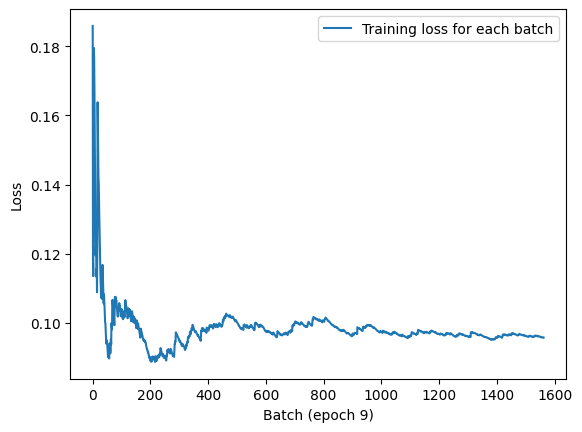

In [10]:
from matplotlib import pyplot as plt

class LossHistory(keras.callbacks.Callback):
    def on_train_begin(self, logs):
        self.per_batch_losses = []
    def on_batch_end(self, batch, logs):
        self.per_batch_losses.append(logs.get('loss'))
    def on_epoch_end(self, epoch, logs):
        plt.clf()
        plt.plot(range(len(self.per_batch_losses)), self.per_batch_losses,
                 label='Training loss for each batch')
        plt.xlabel(f'Batch (epoch {epoch})')
        plt.ylabel('Loss')
        plt.legend()
        plt.savefig(f'plot_at_epoch_{epoch}')
        self.per_batch_losses = []

model = get_mnist_model()
model.compile(optimizer='rmsprop',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
model.fit(train_images, train_labels,
              epochs=10,
              callbacks=[LossHistory()],
              validation_data=(val_images, val_labels))

## Notes

##### 서브클래싱된 모델이 지원하지 않는 것

- 서브클래싱된 모델에서는 모델 로직을 많이 책임져야 하며 잠재적인 오류 가능성이 훨씬 커서, 겨과적으로 더 많은 디버깅 작업을 해야 한다.

- 함수형 모델은 명시적인 데이터 구조인 층의 그래프이므로 출력하고 조사하고 수정할 수 있다. 서브클래싱 모델은 한 덩어리의 바이트코드이다. 원시코드가 담긴 call() 메서드를 가진 파이썬 클래스이다. 

- 예를 들어, 층이 서로 연결되는 방식이 call() 메서드 안에 감추어지기 때문에 이 정보를 활용할 수 없다. summary() 메서드가 층의 연결 구조를 츨력할 수 없고 plot_model() 함수로 모델의 구조를 그래프로 그릴 수 없다.

##### 작업에 적합한 도구 사용하기

- 케라스 모델 구축을 위해 가장 단순한 워크플로인 Sequential 모델부터 가장 고급인 Model 서브클래싱까지 다양한 워크플로가 있다.

- 일반적으로, 함수형 API가 쉬운 사용성과 유연성 사이에 적절한 절충점이다. 층 연결 구조를 활용하여 모델 출력이나 특성 추출과 같은 용도에 잘 맞다. 함수형 API를 사용할 수 있다면, 즉 모델을 층의 유향 비순환 그래프로 표현할 수 있다면 Model 서브클래싱보다 이 방식을 사용하는 것이 낫다.

##### ModelCheckpoint와 EarlyStopping 콜백

- 모델을 훈련할 때는 미리 예상할 수 없는 것이 많다. 특히 최적의 검증 손실을 얻기 위해 얼마나 많은 에포크가 필요한지 알지 못한다. 좋은 처리 방법은 검증 손실이 더 이상 향상되지 않을 때 훈련을 멈추는 것이고, EarlyStopping 콜백을 사용하여 이를 구현할 수 있다. EarlyStopping 콜백은 정해진 에포크 동안 모니터링 지표가 향상되지 않을 때 훈련을 중지한다. 일반적으로 이 콜백은 훈련하는 동안 모델을 계속 저장해주는 ModelCheckpoint 콜백과 함께 사용한다.